# Mouse Muscle-Specific FBA Model via CORDA

Builds a quadriceps muscle-specific metabolic model from iMM1865 (mouse genome-scale model)
using the CORDA algorithm and transcriptome data from GSE17576.

After reconstruction, the exported model is configured for muscle-oriented simulation by maximizing
mitochondrial ATP production (`ATPS4mi` in iMM1865) while enforcing a biomass-maintenance lower
bound at 80% of the reference muscle-model maximum biomass flux.

This is a mouse-equivalent adaptation of the muscle objective strategy described in:
Khoshnejat M, Banaei-Moghaddam AM, Moosavi-Movahedi AA, Kavousi K (2023)
A holistic view of muscle metabolic reprogramming through personalized metabolic modeling in newly
diagnosed diabetic patients. PLoS ONE 18(6): e0287325.
https://doi.org/10.1371/journal.pone.0287325

**To reuse with a different transcriptome dataset:** edit only Cell 0 (USER CONFIG section).

In [11]:
import os

# Run this cell once to install gurobipy if not already installed
import importlib, subprocess, sys
if importlib.util.find_spec('gurobipy') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gurobipy==13.0.1'])
    print('gurobipy installed')
else:
    import gurobipy
    print(f'gurobipy already installed, version {gurobipy.gurobi.version()}')

gurobipy already installed, version (13, 0, 1)


In [12]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 0 — USER CONFIG
# To reuse this notebook with a different transcriptome dataset,
# change only the values in this cell.
# ════════════════════════════════════════════════════════════════════════════════

from pathlib import Path
BASE = Path('..').resolve()

# ── Model ────────────────────────────────────────────────────────────────────
MODEL_PATH = BASE / '4_metabolic_network_reconstruction/iMM1865/iMM1865.xml.xz'

# ── Gene ID cache (Entrez → symbol) ──────────────────────────────────────────
GENE_CACHE = BASE / '1_dataset_transcriptomes/GSE17576/mygene_cache.json'

# ── Transcriptome inputs — CHANGE THESE FOR A DIFFERENT DATASET ──────────────
EXPR_PATH     = BASE / '1_dataset_transcriptomes/GSE17576/normalized_expression.csv.xz'
ANN_PATH      = BASE / '1_dataset_transcriptomes/GSE17576/sample_annotation.csv.xz'
CONDITION_COL = 'condition'   # column in annotation file that labels conditions
GENE_ID_TYPE  = 'symbol'      # 'symbol' or 'entrez' — type of row IDs in expression matrix

# ── Outputs ──────────────────────────────────────────────────────────────────
OUT_MODEL = BASE / '4_metabolic_network_reconstruction/muscle_specific_model.xml'
OUT_JSON  = BASE / '4_metabolic_network_reconstruction/muscle_specific_model.json'
OUT_CONF  = BASE / '4_metabolic_network_reconstruction/muscle_gene_confidence.csv'

# ── CORDA algorithm parameters ───────────────────────────────────────────────
THRESHOLD_METHOD = 'p25_gene_mean'  # 'p25_gene_mean' or 'fixed_log2_4'
CORDA_N          = 3
CORDA_PENALTY    = 100.0
CORDA_SUPPORT    = 5
SOLVER           = 'gurobi'         # 'gurobi' (fast) or 'glpk' (fallback)

# ── Muscle objective configuration ───────────────────────────────────────────
ATP_OBJECTIVE_RXN_ID   = 'ATPS4mi'
BIOMASS_RXN_ID         = 'BIOMASS_reaction'
BIOMASS_LB_FRACTION    = 0.8
PROTECTED_REACTION_IDS = [ATP_OBJECTIVE_RXN_ID, BIOMASS_RXN_ID]

# ─────────────────────────────────────────────────────────────────────────────

# CORDA confidence values (do not change)
CONF_HC = 3    # High confidence: expressed in all conditions
CONF_MC = 1    # Medium confidence: expressed in some conditions
CONF_LC = -1   # Low confidence: absent in all conditions
CONF_NC = 0    # Not considered: not in expression data

print('Config loaded.')
print(f'  Expression : {EXPR_PATH}')
print(f'  Annotation : {ANN_PATH}')
print(f'  Model      : {MODEL_PATH}')
print(f'  Solver     : {SOLVER}')
print(f'  ATP obj    : {ATP_OBJECTIVE_RXN_ID}')
print(f'  Biomass    : {BIOMASS_RXN_ID} @ {BIOMASS_LB_FRACTION:.0%} of max')
print(f'  Protected  : {PROTECTED_REACTION_IDS}')

Config loaded.
  Expression : /home/pty/work/DMI_GEM_APBC2026/1_dataset_transcriptomes/GSE17576/normalized_expression.csv.xz
  Annotation : /home/pty/work/DMI_GEM_APBC2026/1_dataset_transcriptomes/GSE17576/sample_annotation.csv.xz
  Model      : /home/pty/work/DMI_GEM_APBC2026/4_metabolic_network_reconstruction/iMM1865/iMM1865.xml.xz
  Solver     : gurobi
  ATP obj    : ATPS4mi
  Biomass    : BIOMASS_reaction @ 80% of max
  Protected  : ['ATPS4mi', 'BIOMASS_reaction']


In [13]:
# ── Imports ───────────────────────────────────────────────────────────────────
import lzma, json, tempfile, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cobra
import cobra.io
from corda import CORDA, reaction_confidence

warnings.filterwarnings('ignore')
print(f'COBRApy {cobra.__version__}')
import corda as _corda_mod
print(f'CORDA   {_corda_mod.__version__}')

COBRApy 0.31.1
CORDA   0.5.1


## Cell 1 — Load iMM1865 Model

In [14]:
def load_model(path):
    """Load an xz-compressed SBML model. libSBML needs a real file path."""
    with lzma.open(path, 'rb') as f_in:
        xml_bytes = f_in.read()
    with tempfile.NamedTemporaryFile(suffix='.xml', delete=False) as tmp:
        tmp.write(xml_bytes)
        tmp_path = tmp.name
    try:
        m = cobra.io.read_sbml_model(tmp_path)
    finally:
        os.unlink(tmp_path)
    return m

model = load_model(MODEL_PATH)
print(f'Reactions  : {len(model.reactions):,}')
print(f'Metabolites: {len(model.metabolites):,}')
print(f'Genes      : {len(model.genes):,}')

# Verify feasibility
sol = model.optimize()
print(f'\nFull model FBA: {sol.status}, objective = {sol.objective_value:.4f}')

Reactions  : 10,612
Metabolites: 5,839
Genes      : 1,865

Full model FBA: optimal, objective = 798.8111


## Cell 2 — Load Expression Data & Compute Condition Means

In [15]:
def load_expression(expr_path, ann_path):
    expr = pd.read_csv(expr_path, index_col=0, compression='xz')
    ann  = pd.read_csv(ann_path,  index_col=0, compression='xz')
    expr.index.name = 'gene'
    print(f'Expression : {expr.shape[0]:,} genes × {expr.shape[1]} samples')
    print(f'Conditions : {dict(ann[CONDITION_COL].value_counts())}')
    return expr, ann

def compute_condition_means(expr, ann):
    """Return DataFrame (genes × conditions) of per-condition mean expression."""
    return pd.DataFrame({
        cond: expr[grp.index].mean(axis=1)
        for cond, grp in ann.groupby(CONDITION_COL)
    })

expr, ann   = load_expression(EXPR_PATH, ANN_PATH)
cond_df     = compute_condition_means(expr, ann)
print(f'\nCondition mean matrix: {cond_df.shape}')
cond_df.describe()

Expression : 16,319 genes × 30 samples
Conditions : {'LFD_day0': np.int64(10), 'LFD_day56': np.int64(10), 'HFD_day56': np.int64(10)}

Condition mean matrix: (16319, 3)


,HFD_day56,LFD_day0,LFD_day56
count,16319.000000,16319.000000,16319.000000
mean,4.549857,4.550981,4.545343
std,2.674270,2.677220,2.681500
min,1.325536,1.315095,1.332356
25%,2.385154,2.374390,2.369703
50%,3.366264,3.372638,3.353366
75%,6.449222,6.462869,6.459321
max,14.818310,14.806399,14.813951


## Cell 3 — Threshold Selection & HC/MC/LC Classification

Threshold  : 2.3744 (log2)  ≈  linear 5.2x
Classification (all 16,319 genes):
HC    11940
LC     3735
MC      644


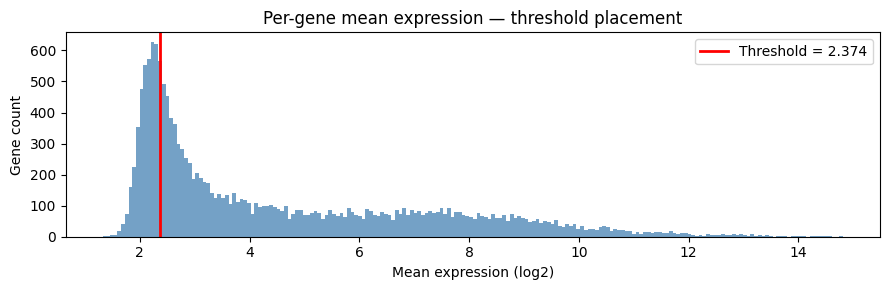

In [16]:
def choose_threshold(cond_df, method='p25_gene_mean'):
    """
    Select an expression threshold.

    'p25_gene_mean': 25th percentile of per-gene grand means.
        Chosen because log2(4)=2.0 classifies ~93% of genes as expressed
        (RMA normalisation floor), giving CORDA almost no pruning signal.
        The p25 separates the lower quartile of genes (tissue-absent) from
        the upper three quarters (tissue-expressed).
    'fixed_log2_4': log2(4) = 2.0, a common microarray expressed cutoff.
    """
    if method == 'fixed_log2_4':
        return 2.0
    elif method == 'p25_gene_mean':
        return float(np.percentile(cond_df.mean(axis=1), 25))
    else:
        raise ValueError(f'Unknown threshold method: {method}')

def classify_genes(cond_df, threshold):
    """
    Classify each gene as HC / MC / LC.
      HC (3): mean > threshold in ALL conditions
      MC (1): mean > threshold in SOME conditions
      LC (-1): mean ≤ threshold in ALL conditions
    Returns Series indexed by gene identifier.
    """
    above = cond_df > threshold
    conf  = pd.Series(CONF_LC, index=cond_df.index, dtype=int)
    conf[above.any(axis=1) & ~above.all(axis=1)] = CONF_MC
    conf[above.all(axis=1)]                       = CONF_HC
    return conf

threshold     = choose_threshold(cond_df, method=THRESHOLD_METHOD)
gene_conf_sym = classify_genes(cond_df, threshold)

counts = gene_conf_sym.value_counts().rename({CONF_HC: 'HC', CONF_MC: 'MC', CONF_LC: 'LC'})
print(f'Threshold  : {threshold:.4f} (log2)  ≈  linear {2**threshold:.1f}x')
print(f'Classification (all {len(gene_conf_sym):,} genes):')
print(counts.to_string())

# Visualise threshold placement
fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(cond_df.mean(axis=1), bins=200, color='steelblue', alpha=0.75)
ax.axvline(threshold, color='red', lw=2, label=f'Threshold = {threshold:.3f}')
ax.set_xlabel('Mean expression (log2)'); ax.set_ylabel('Gene count')
ax.set_title('Per-gene mean expression — threshold placement')
ax.legend(); plt.tight_layout(); plt.show()

## Cell 4 — Map Gene IDs → Entrez IDs & Assign Model Gene Confidence

In [17]:
def build_symbol_to_entrez(cache_path):
    """Reverse the mygene cache {entrez: symbol} → {symbol: entrez}."""
    with open(cache_path) as f:
        entrez2sym = json.load(f)
    sym2entrez = {}
    for eid, sym in entrez2sym.items():
        if sym and sym not in sym2entrez:
            sym2entrez[sym] = eid
    print(f'Symbol→Entrez map: {len(sym2entrez):,} entries')
    return sym2entrez

def map_confidence_to_entrez(gene_conf, gene_id_type, sym2entrez):
    """
    Convert gene confidence from expression-matrix IDs to Entrez IDs.
    gene_id_type: 'symbol' (use sym2entrez) or 'entrez' (use directly).
    """
    conf_entrez = {}
    unmapped    = []
    for gid, conf in gene_conf.items():
        if gene_id_type == 'entrez':
            conf_entrez[str(gid)] = int(conf)
        else:
            eid = sym2entrez.get(gid)
            if eid is None:
                unmapped.append(gid)
            else:
                conf_entrez[eid] = int(conf)
    if unmapped:
        print(f'Symbols not in cache (dropped): {len(unmapped)}  '
              f'e.g. {unmapped[:5]}')
    print(f'Entrez confidence map: {len(conf_entrez):,} entries')
    return conf_entrez

sym2entrez  = build_symbol_to_entrez(GENE_CACHE)
conf_entrez = map_confidence_to_entrez(gene_conf_sym, GENE_ID_TYPE, sym2entrez)

# Breakdown for model genes
model_gene_ids = {g.id for g in model.genes}
in_expr        = {eid: c for eid, c in conf_entrez.items() if eid in model_gene_ids}
not_in_expr    = model_gene_ids - set(conf_entrez.keys())
label_map      = {CONF_HC: 'HC', CONF_MC: 'MC', CONF_LC: 'LC', CONF_NC: 'NC'}

print(f'\nModel genes in expression data : {len(in_expr):,}')
print(f'Model genes absent (→ NC=0)    : {len(not_in_expr):,}')
cnt = Counter(label_map[c] for c in in_expr.values())
print(f'Model gene breakdown: {dict(cnt)}')

# Save audit table
rows = []
for g in model.genes:
    c = conf_entrez.get(g.id, CONF_NC)
    rows.append({'entrez_id': g.id, 'gene_name': g.name,
                 'confidence': c, 'label': label_map.get(c, str(c))})
pd.DataFrame(rows).to_csv(OUT_CONF, index=False)
print(f'\nGene confidence saved: {OUT_CONF}')

Symbol→Entrez map: 16,319 entries
Entrez confidence map: 16,319 entries

Model genes in expression data : 1,647
Model genes absent (→ NC=0)    : 218
Model gene breakdown: {'HC': 1241, 'LC': 352, 'MC': 54}

Gene confidence saved: /home/pty/work/DMI_GEM_APBC2026/4_metabolic_network_reconstruction/muscle_gene_confidence.csv


## Cell 5 — Compute Reaction Confidence Scores

In [18]:
def build_reaction_confidence(model, conf_entrez, default_no_gpr=CONF_NC,
                              protected_reaction_ids=PROTECTED_REACTION_IDS):
    """
    Map per-gene confidence to per-reaction confidence via GPR rules.
      OR  nodes → max of children (isoenzymes: any one sufficient)
      AND nodes → min of children (complex: all subunits needed)
    Reactions without GPR (exchange, transport, spontaneous) → default_no_gpr.

    The ATP objective and biomass maintenance reactions are promoted so CORDA
    retains the reactions needed for the downstream paper-style muscle simulation.
    """
    rxn_conf = {}
    for rxn in model.reactions:
        if rxn.gene_reaction_rule.strip():
            rxn_conf[rxn.id] = reaction_confidence(rxn, conf_entrez)
        else:
            rxn_conf[rxn.id] = default_no_gpr

    protected_present = []
    protected_missing = []
    for rid in protected_reaction_ids:
        if rid in rxn_conf:
            rxn_conf[rid] = max(rxn_conf[rid], CONF_HC)
            protected_present.append(rid)
        else:
            protected_missing.append(rid)

    if protected_present:
        print(f'Protected reactions forced to HC: {protected_present}')
    if protected_missing:
        print(f'WARNING: protected reactions not found in base model: {protected_missing}')
    return rxn_conf

rxn_conf = build_reaction_confidence(model, conf_entrez)

label_map2 = {CONF_HC: 'HC (3)', CONF_MC: 'MC (1)', CONF_LC: 'LC (-1)', CONF_NC: 'NC (0)'}
cnt = Counter(label_map2.get(c, str(c)) for c in rxn_conf.values())
print('Reaction confidence distribution:')
for k in ['HC (3)', 'MC (1)', 'NC (0)', 'LC (-1)']:
    print(f'  {k:10s}: {cnt.get(k, 0):,}')

Protected reactions forced to HC: ['ATPS4mi', 'BIOMASS_reaction']
Reaction confidence distribution:
  HC (3)    : 4,939
  MC (1)    : 148
  NC (0)    : 4,879
  LC (-1)   : 646


## Cell 6 — Run CORDA

In [ ]:
def run_corda(model, rxn_conf, solver=SOLVER,
              n=CORDA_N, penalty_factor=CORDA_PENALTY, support=CORDA_SUPPORT):
    m = model.copy()
    try:
        m.solver = solver
        # Quick feasibility check to catch license errors early
        m.optimize()
        print(f'Solver: {solver}')
    except Exception as e:
        print(f'{solver} unavailable ({e}), falling back to glpk')
        m.solver = 'glpk'
    opt = CORDA(model=m, confidence=rxn_conf,
                n=n, penalty_factor=penalty_factor, support=support)
    print(f'Running CORDA (n={n}, penalty={penalty_factor}, support={support}) ...')
    opt.build()
    return opt

corda_opt = run_corda(model, rxn_conf)
print(corda_opt)

Read LP format model from file /tmp/tmpb5585ecy.lp
Reading time = 0.03 seconds
: 5839 rows, 21224 columns, 80812 nonzeros
Solver: gurobi
Read LP format model from file /tmp/tmpvmef4jx9.lp
Reading time = 0.02 seconds
: 5839 rows, 21224 columns, 80812 nonzeros
Running CORDA (n=3, penalty=100.0, support=5) ...


## Cell 7 — Extract, Configure, Validate & Save the Muscle Model

This cell applies the muscle-oriented simulation setup after CORDA reconstruction.
It uses the mouse-equivalent mitochondrial ATP production objective and enforces a
biomass-maintenance lower bound at 80% of the reconstructed healthy/reference model's
maximum biomass flux, following the strategy described by Khoshnejat et al. (2023).

To support that downstream simulation, the ATP objective and biomass maintenance
reactions are explicitly protected during reconstruction so they are retained in the
final muscle model before the objective is switched.

In [ ]:
def validate_and_save(corda_opt, original_model, rxn_conf, out_xml, out_json,
                      atp_objective_rxn_id=ATP_OBJECTIVE_RXN_ID,
                      biomass_rxn_id=BIOMASS_RXN_ID,
                      biomass_lb_fraction=BIOMASS_LB_FRACTION):
    muscle_model = corda_opt.cobra_model(name='iMM1865_muscle')
    print(f'Muscle model  : {len(muscle_model.reactions):,} reactions, '
          f'{len(muscle_model.metabolites):,} metabolites, '
          f'{len(muscle_model.genes):,} genes')
    pct = 100 * len(muscle_model.reactions) / len(original_model.reactions)
    print(f'Size retained : {pct:.1f}% of original reactions')

    muscle_ids = {r.id for r in muscle_model.reactions}

    if atp_objective_rxn_id not in muscle_ids:
        raise KeyError(
            f'ATP objective reaction {atp_objective_rxn_id!r} not found in reconstructed model.'
        )
    if biomass_rxn_id not in muscle_ids:
        raise KeyError(
            f'Biomass reaction {biomass_rxn_id!r} not found in reconstructed model.'
        )

    atp_rxn = muscle_model.reactions.get_by_id(atp_objective_rxn_id)
    biomass_rxn = muscle_model.reactions.get_by_id(biomass_rxn_id)

    # Baseline feasibility before switching to the paper-inspired muscle objective.
    baseline_sol = muscle_model.optimize()
    print(f'\nBaseline FBA status : {baseline_sol.status}')
    if baseline_sol.status == 'optimal':
        print(f'Baseline objective  : {baseline_sol.objective_value:.4f}')
    else:
        print('WARNING: muscle model is infeasible before objective reconfiguration.')

    with muscle_model as biomass_model:
        biomass_model.objective = biomass_model.reactions.get_by_id(biomass_rxn_id)
        biomass_sol = biomass_model.optimize()

    print(f'Biomass reference rxn: {biomass_rxn_id}')
    print(f'ATP objective rxn    : {atp_objective_rxn_id}')
    print(f'Biomass max status   : {biomass_sol.status}')
    if biomass_sol.status != 'optimal' or biomass_sol.objective_value is None:
        raise RuntimeError('Could not compute reference maximum biomass flux.')

    max_biomass = float(biomass_sol.objective_value)
    biomass_lower_bound = biomass_lb_fraction * max_biomass
    biomass_rxn.lower_bound = biomass_lower_bound
    print(f'Max biomass flux     : {max_biomass:.6f}')
    print(f'Applied biomass LB   : {biomass_lower_bound:.6f} ({biomass_lb_fraction:.0%} of max)')

    muscle_model.objective = atp_rxn
    sol = muscle_model.optimize()
    print(f'ATP-max FBA status   : {sol.status}')
    if sol.status == 'optimal':
        print(f'ATP objective value  : {sol.objective_value:.4f}')
    else:
        print('WARNING: ATP-maximizing muscle model is infeasible after biomass constraint.')

    # HC reactions present
    hc_ids     = {rid for rid, c in rxn_conf.items() if c == CONF_HC}
    missing_hc = hc_ids - muscle_ids
    if missing_hc:
        print(f'\nWARNING: {len(missing_hc)} HC reactions missing (likely impossible):')
        for rid in list(missing_hc)[:10]:
            print(f'  {rid}')
    else:
        print(f'\nAll {len(hc_ids):,} HC reactions retained.')

    # Key muscle pathway checks
    KEY_REACTIONS = ['PDHm', 'CS', atp_objective_rxn_id, 'PFK', 'LDH_L', 'CPT1', biomass_rxn_id]
    print('\nKey muscle reactions:')
    for rid in KEY_REACTIONS:
        status = 'PRESENT' if rid in muscle_ids else 'absent'
        print(f'  {rid:30s}: {status}')

    # Save
    cobra.io.write_sbml_model(muscle_model, out_xml)
    cobra.io.save_json_model(muscle_model, out_json)
    print(f'\nSaved SBML : {out_xml}')
    print(f'Saved JSON : {out_json}')
    return muscle_model

muscle_model = validate_and_save(corda_opt, model, rxn_conf, OUT_MODEL, OUT_JSON)

Read LP format model from file /tmp/tmpfkh10z4m.lp
Reading time = 0.02 seconds
: 5839 rows, 21224 columns, 80812 nonzeros
Muscle model  : 7,653 reactions, 4,913 metabolites, 1,745 genes
Size retained : 72.1% of original reactions

Baseline FBA status : optimal
Baseline objective  : 556.6115
Biomass reference rxn: BIOMASS_reaction
ATP objective rxn    : ATPS4mi
Biomass max status   : optimal
Max biomass flux     : 556.611521
Applied biomass LB   : 445.289217 (80% of max)
ATP-max FBA status   : optimal
ATP objective value  : 1000.0000

All 4,939 HC reactions retained.

Key muscle reactions:
  PDHm                          : PRESENT
  CS                            : absent
  ATPS4mi                       : PRESENT
  PFK                           : PRESENT
  LDH_L                         : PRESENT
  CPT1                          : absent
  BIOMASS_reaction              : PRESENT

Saved SBML : /home/pty/work/project_MRI/metabolic_network/muscle_specific_model.xml
Saved JSON : /home/pty/work

## Cell 8 — Diagnostics: Subsystem Coverage & CORDA Impossible List

In [ ]:
# Subsystem coverage
def subsystem_coverage(original, tissue):
    def count_subsystems(m):
        c = Counter()
        for r in m.reactions:
            ss = (r.subsystem or 'unknown').strip() or 'unknown'
            c[ss] += 1
        return c
    orig_cnt   = count_subsystems(original)
    tissue_cnt = count_subsystems(tissue)
    df = pd.DataFrame({'original': orig_cnt, 'muscle': tissue_cnt}).fillna(0).astype(int)
    df['fraction'] = (df['muscle'] / df['original']).round(3)
    return df.sort_values('muscle', ascending=False)

ss_df = subsystem_coverage(model, muscle_model)
print('Top 25 retained subsystems (by muscle reaction count):')
print(ss_df.head(25).to_string())

# CORDA impossible list
impossible = corda_opt.impossible
print(f'\nCORDA impossible HC reactions: {len(impossible)}')
if len(impossible) > 0:
    print('(HC reactions that cannot carry sufficient flux in the base model)')
    for rid in impossible[:20]:
        try:
            rxn = model.reactions.get_by_id(rid)
            print(f'  {rid:35s} | {rxn.reaction[:55]}')
        except KeyError:
            print(f'  {rid}')

Top 25 retained subsystems (by muscle reaction count):
                                  original  muscle  fraction
Transport, extracellular              2652    1940     0.732
Exchange/demand reaction              1788     997     0.558
Fatty acid oxidation                   961     914     0.951
Drug metabolism                        573     331     0.578
Transport, mitochondrial               452     331     0.732
Cholesterol metabolism                 242     233     0.963
Fatty acid synthesis                   239     220     0.921
Transport, endoplasmic reticular       211     155     0.735
Glycerophospholipid metabolism         164     145     0.884
Nucleotide interconversion             165     144     0.873
Bile acid synthesis                    185     134     0.724
Transport, peroxisomal                 154     128     0.831
Miscellaneous                          152     128     0.842
Sphingolipid metabolism                134     122     0.910
Transport, lysosomal          